In [1]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath("..")) 

import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax.random as jr
from models.opinon import OpinionGraph

key=jr.PRNGKey(42)

In [2]:
G = OpinionGraph(n=200, alpha=5.0)
G.positions()
G.distances()
G.distance_based_graphon(k=1.0, lam=0.1) 

def polarization_strategy(x):
    # example strategy: 
    # first half of individuals pushed to opinion 0.2, 
    # second halp pushed to 0.8
    return jnp.where(x < 0.5, 0.2, 0.8)

def constant_strength(x):   
    # example constant strength of 2
    return jnp.ones_like(x) * 0.5

G.set_external_field(O_func=polarization_strategy, Gamma_func=constant_strength)

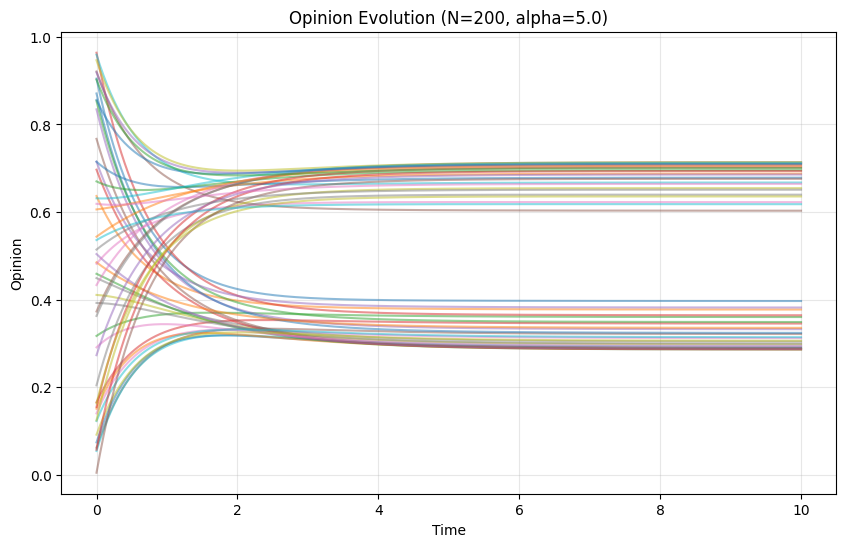

In [4]:

# simulate dynamics
sol = G.solve(T=10.0, dt=0.01, phi_type='linear')

# visualize solution evolution
G.plot_time_evolution(sol)


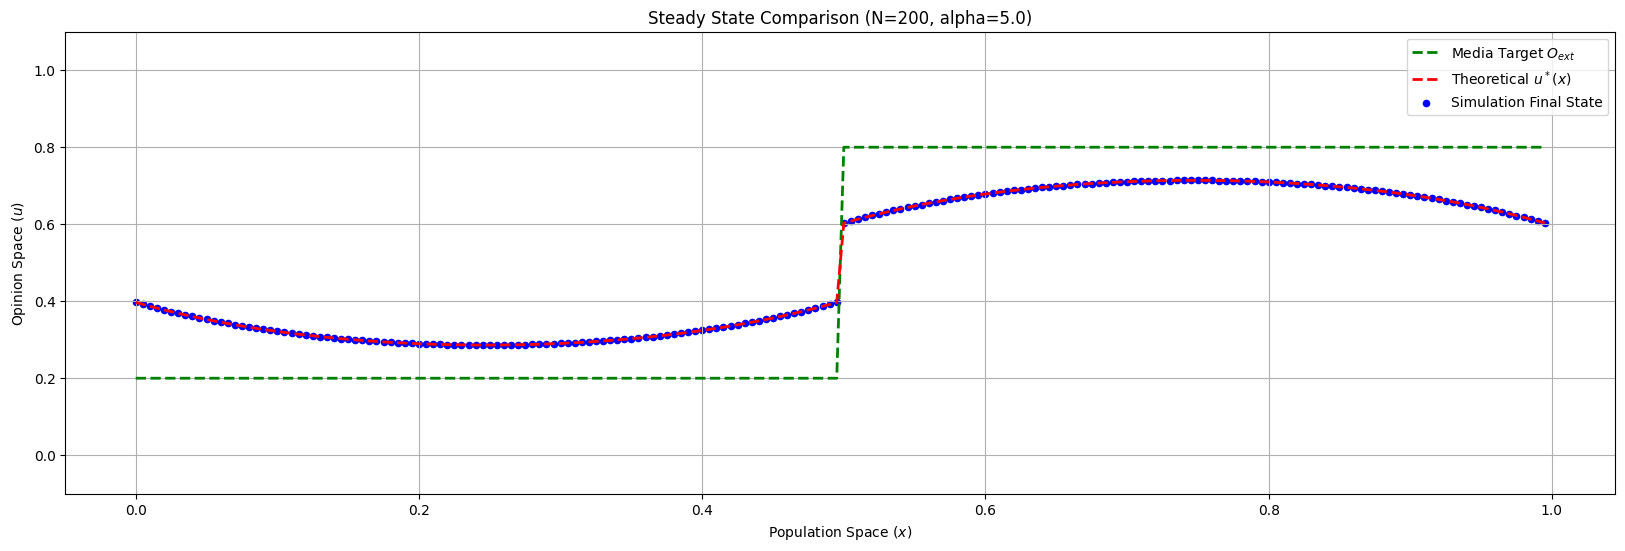

In [5]:

alpha = G.alpha
N = G.n
A = G.A
Gamma = G.Gamma  
O_ext = G.O_ext  

# total internal connectivity
C_int = jnp.sum(A, axis=1) / N

# discretize and solve linear system
M = jnp.diag(alpha * C_int + Gamma) - ((alpha / N) * A )
b = Gamma * O_ext
u_theory = jnp.linalg.solve(M, b)

u_theory = jnp.linalg.solve(M, b)

x_plot = np.array(G.x)
sim_final = np.array(sol.ys[-1])
theory_final = np.array(u_theory)
media_target = np.array(G.O_ext)

plt.figure(figsize=(20, 6))

plt.plot(x_plot, media_target, 'g--', linewidth=2, label='Media Target $O_{ext}$')
plt.plot(x_plot, theory_final, 'r--', linewidth=2, label='Theoretical $u^*(x)$')
plt.scatter(x_plot, sim_final, color='blue', alpha=1, s=20, label='Simulation Final State')

plt.ylim(-0.1, 1.1)
plt.xlabel('Population Space ($x$)')
plt.ylabel('Opinion Space ($u$)')
plt.grid(True)
plt.title(f'Steady State Comparison (N={N}, alpha={alpha})')
plt.legend()

In [58]:
MSE = jnp.sum((sim_final-u_theory)**2)
print("Mean squared error between theoretical and simulated steady state: \n", MSE)

Mean squared error between theoretical and simulated steady state: 
 2.0849866e-06


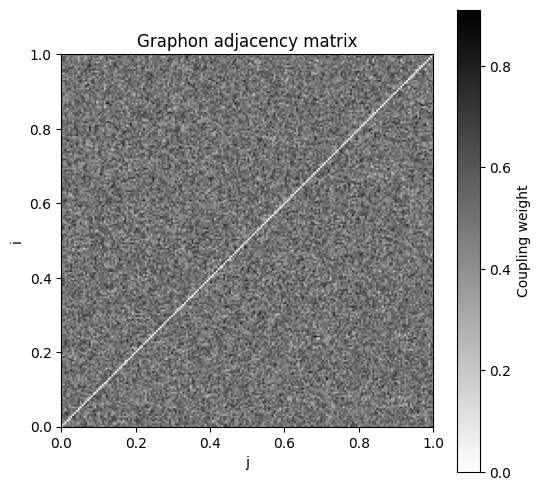

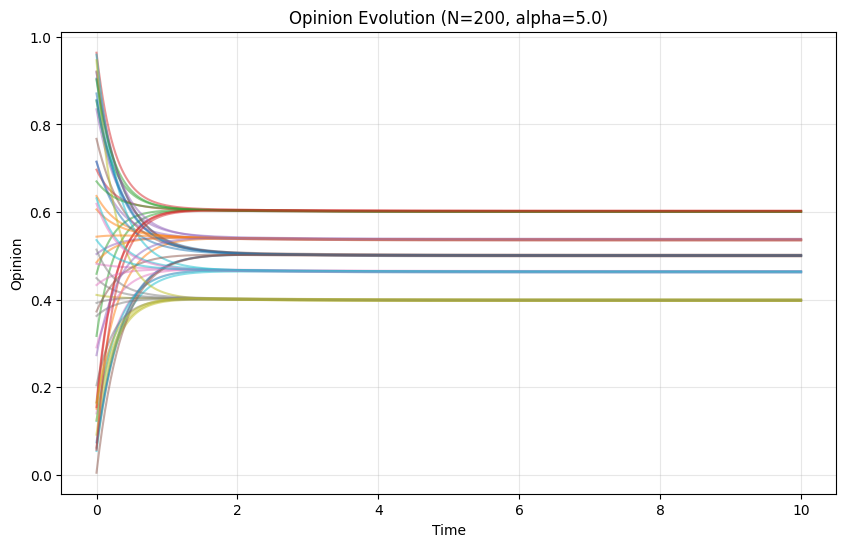

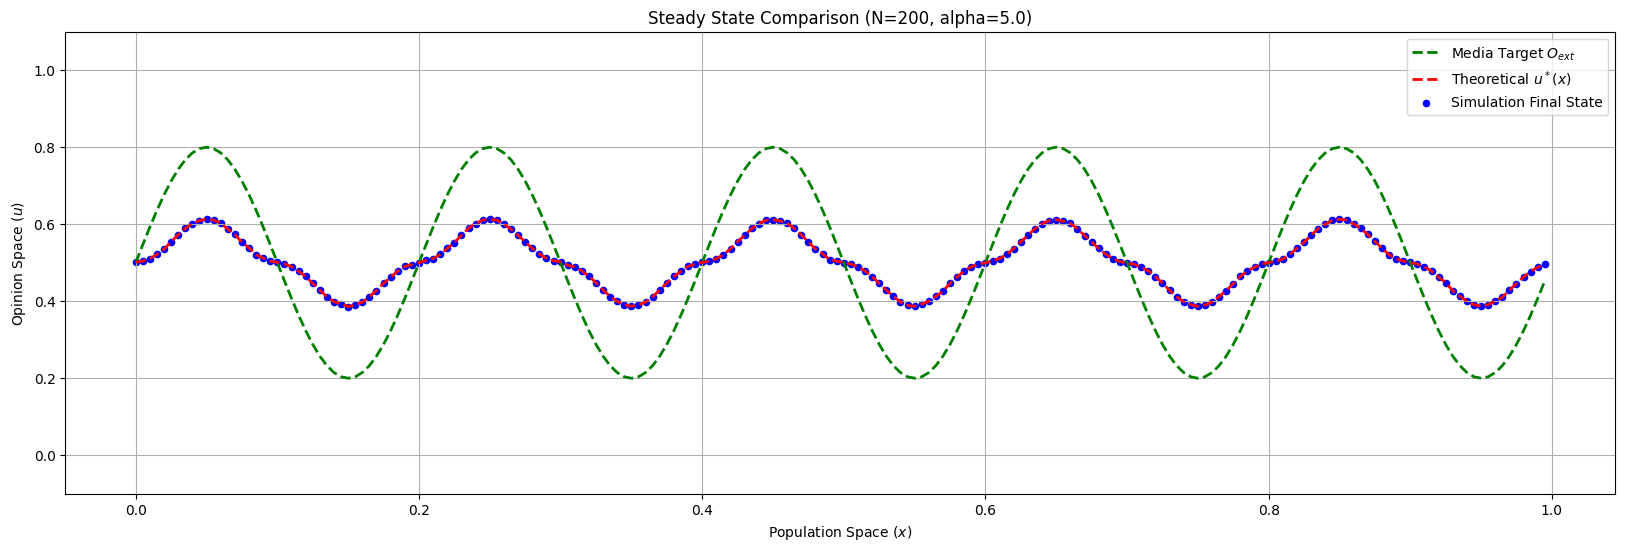

In [ ]:
def oscillatory_strategy(x):
    return 0.5 + 0.3 * jnp.sin(10 * jnp.pi * x)

G = OpinionGraph(n=200, alpha=5.0)
G.positions()
G.distances()
G.random_graphon(key=key) 
G.plot_graphon()


def oscillatory_strength(x):
    return 0.7 + 0.5 * jnp.cos(10 * jnp.pi * x)

def turning_point_strength(x, min_strength=0.2, max_strength=1.5, freq=10.0, phi=0.0, sharpness=2.0):
    """
    Strength maximizes where |sin(...)| is 1 (turning points)
    and minimizes where sin(...) == 0 (axis of symmetry).
    """
    s = jnp.abs(jnp.sin(freq * jnp.pi * x + phi))
    return min_strength + (max_strength - min_strength) * (s ** sharpness)


G.set_external_field(O_func=oscillatory_strategy, Gamma_func=turning_point_strength)


# simulate dynamics
sol = G.solve(T=10.0, dt=0.01, phi_type='linear')

# visualize solution evolution
G.plot_time_evolution(sol)


alpha = G.alpha
N = G.n
A = G.A
Gamma = G.Gamma  
O_ext = G.O_ext  

# total internal connectivity
C_int = jnp.sum(A, axis=1) / N

# discretize and solve linear system
# note: this integral can be solved without dscretization for some graphons (e.g. constan, exp, analystical)
M = jnp.diag(alpha * C_int + Gamma) - ((alpha / N) * A )
b = Gamma * O_ext
u_theory = jnp.linalg.solve(M, b)

u_theory = jnp.linalg.solve(M, b)

x_plot = np.array(G.x)
sim_final = np.array(sol.ys[-1])
theory_final = np.array(u_theory)
media_target = np.array(G.O_ext)

plt.figure(figsize=(20, 6))

plt.plot(x_plot, media_target, 'g--', linewidth=2, label='Media Target $O_{ext}$')
plt.plot(x_plot, theory_final, 'r--', linewidth=2, label='Theoretical $u^*(x)$')
plt.scatter(x_plot, sim_final, color='blue', alpha=1, s=20, label='Simulation Final State')

plt.ylim(-0.1, 1.1)
plt.xlabel('Population Space ($x$)')
plt.ylabel('Opinion Space ($u$)')
plt.grid(True)
plt.title(f'Steady State Comparison (N={N}, alpha={alpha})')
plt.legend()


In [13]:
MSE = jnp.sum((sim_final-u_theory)**2)
print("Mean squared error between theoretical and simulated steady state: \n", MSE)

Mean squared error between theoretical and simulated steady state: 
 1.6569098e-07


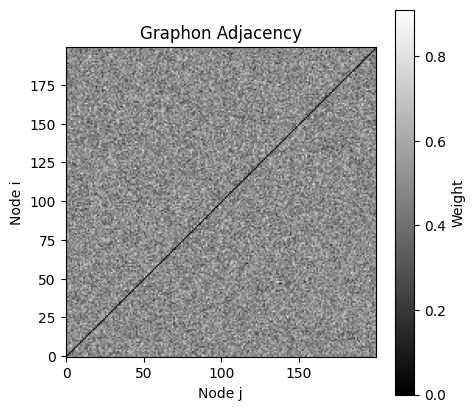

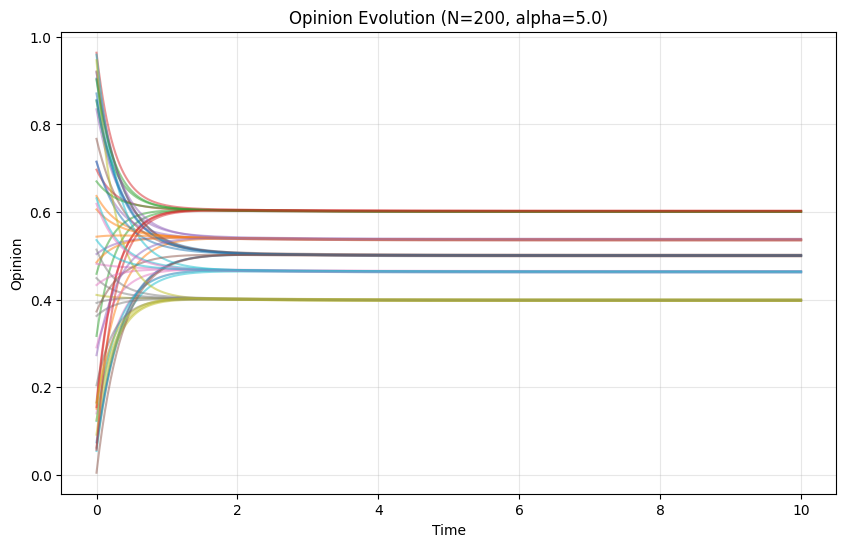

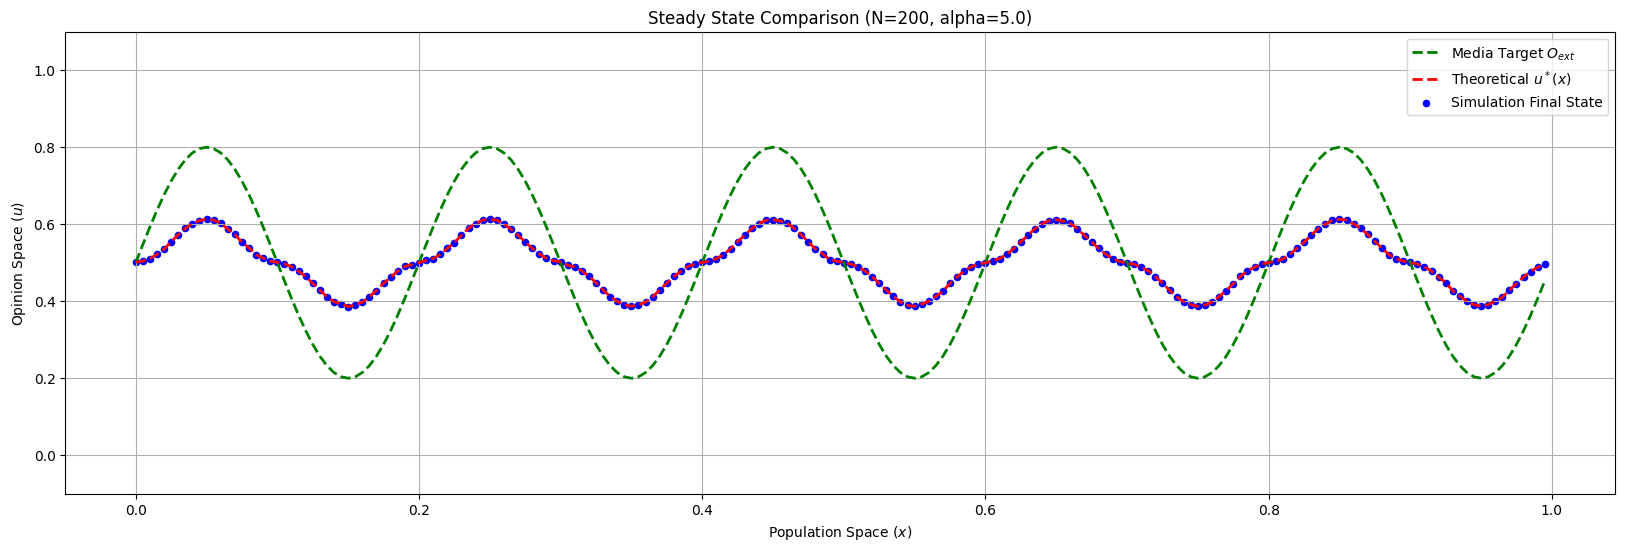

In [6]:
def oscillatory_strategy(x):
    return 0.5 + 0.3 * jnp.sin(10 * jnp.pi * x)

G = OpinionGraph(n=200, alpha=5.0)
G.positions()
G.distances()
G.random_graphon(key=key) 

def oscillatory_strength(x):
    return 0.7 + 0.5 * jnp.cos(10 * jnp.pi * x)

def turning_point_strength(x, min_strength=0.2, max_strength=1.5, freq=10.0, phi=0.0, sharpness=2.0):
    """
    Strength maximizes where |sin(...)| is 1 (turning points)
    and minimizes where sin(...) == 0 (axis of symmetry).
    """
    s = jnp.abs(jnp.sin(freq * jnp.pi * x + phi))
    return min_strength + (max_strength - min_strength) * (s ** sharpness)


G.set_external_field(O_func=oscillatory_strategy, Gamma_func=turning_point_strength)


# simulate dynamics
sol = G.solve(T=10.0, dt=0.01, phi_type='linear')

# visualize solution evolution
G.plot_time_evolution(sol)


alpha = G.alpha
N = G.n
A = G.A
Gamma = G.Gamma  
O_ext = G.O_ext  

# total internal connectivity
C_int = jnp.sum(A, axis=1) / N

# discretize and solve linear system
M = jnp.diag(alpha * C_int + Gamma) - ((alpha / N) * A )
b = Gamma * O_ext
u_theory = jnp.linalg.solve(M, b)

u_theory = jnp.linalg.solve(M, b)

x_plot = np.array(G.x)
sim_final = np.array(sol.ys[-1])
theory_final = np.array(u_theory)
media_target = np.array(G.O_ext)

plt.figure(figsize=(20, 6))

plt.plot(x_plot, media_target, 'g--', linewidth=2, label='Media Target $O_{ext}$')
plt.plot(x_plot, theory_final, 'r--', linewidth=2, label='Theoretical $u^*(x)$')
plt.scatter(x_plot, sim_final, color='blue', alpha=1, s=20, label='Simulation Final State')

plt.ylim(-0.1, 1.1)
plt.xlabel('Population Space ($x$)')
plt.ylabel('Opinion Space ($u$)')
plt.grid(True)
plt.title(f'Steady State Comparison (N={N}, alpha={alpha})')
plt.legend()
